<div class='alert alert-block alert-info"'>
<h1> An sdg4varselect example :</h1>

<h4> Variable selection and estimation in a joint model of logitic longitudinal data and survival data </h4>
</div>

In [1]:
import sdg4varselect.plot as sdgplt
import jax.numpy as jnp
import jax.random as jrd

### Dataset generation

First, let's generate a data set corresponding to a joint model of longitduinal logistic data and a Cox model.


$$ \left\{\begin{array}{rll}
            h(t|U_i) 
            &=h_{0}(t) \exp(\beta^T U_i + \alpha m(t,\varphi_i))
            \\ Y_{i,j} &= m(t_j; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $m(t_j; \varphi_i) = \frac{\varphi_{1,i}}{1+\exp\left(\frac{\varphi_{2,i}-t_j}{\varphi_{3,i}} \right)}$ and $h_{0}(t)= b a^{-b} t^{b-1}$ with $a=80$ and $b=35$

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


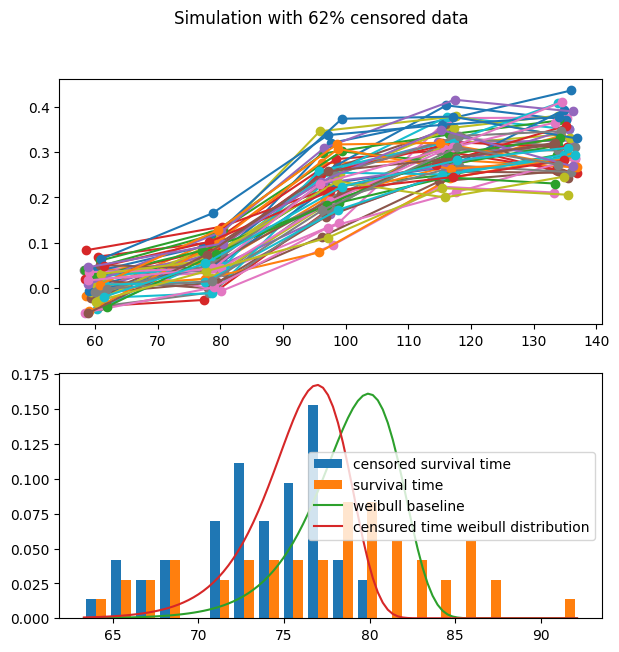

In [2]:
from sdg4varselect.logistic import Logistic_JM
from sdg4varselect.data_handler import DataHandler

model = Logistic_JM(N=50, J=5, DIM_HD=5)

# Simulation parameter
params_star = model.new_params(
    mu1=0.3,
    mu2=90.0,
    mu3=7.5,
    gamma2_1=0.0025,
    gamma2_2=20,
    sigma2=0.001,
    alpha=11.11,
    beta=jnp.concatenate(
        [jnp.array([-2, -3, 3, 2]), jnp.zeros(shape=(model.DIM_HD - 4,))]
    ),
)

obs, sim = model.sample(params_star, jrd.PRNGKey(0), weibull_censoring_loc=77)

dh = DataHandler()
dh.add_data(**obs)

_ = sdgplt.plot_sample(obs, sim, params_star, 77, 80, 35)

# Estimation example

try an estimation on the data set with the SPG-FIM algorithm

first we need to intiate the algorithm with accurate step size.

In [3]:
from sdg4varselect.algo import SPG_FIM

# algorithm settings
algo_settings = SPG_FIM.settings(
    step_size_grad={
        "learning_rate": 1e-8,
        "preheating": 400,
        "heating": 600,
        "max": 0.9,
    },
    step_size_approx_sto={
        "learning_rate": 1e-8,
        "preheating": 400,
        "heating": None,
        "max": 1,
    },
    step_size_fisher={
        "learning_rate": 1e-8,
        "preheating": 400,
        "heating": None,
        "max": 0.9,
    },
    max_iter=2000,
)

# for only estimation we set lambda = None
algo = SPG_FIM(jrd.PRNGKey(0), dh, algo_settings, lbd=None)
# We define the init value of the alogirthm drawn from a normal distribution
theta0 = 0.2 * jrd.normal(jrd.PRNGKey(0), shape=(model.parametrization.size,))

we set $\varphi_1$ and $\varphi_2$ as latente variable, and use a MCMC-procedure in the algorithm to treat them :

In [4]:
params0 = model.parametrization.reals1d_to_params(theta0)
algo.add_mcmc(
    0.2,
    sd=0.001,
    size=model.N,
    likelihood=model.likelihood_array,
    name="phi1",
)
algo.latent_variables["phi1"].adaptative_sd = True
algo.add_mcmc(
    45,
    sd=2,
    size=model.N,
    likelihood=model.likelihood_array,
    name="phi2",
)
algo.latent_variables["phi2"].adaptative_sd = True

In [5]:
from sdg4varselect.algo import NanError, estim_res

try:
    res_estim = algo.fit(
        model.jac_likelihood,
        DIM_HD=model.DIM_HD,
        theta0_reals1d=theta0,
        ntry=5,
        partial_fit=False,
    )
except NanError as err:
    print(err)

res = algo.labelswitch(res_estim)

theta = jnp.array([model.reals1d_to_hstack_params(t) for t in res.theta])
res = estim_res(
    theta=theta,
    FIM=res.FIM,
    grad=res.grad,
    likelihood=algo.likelihood_marginal(model, jrd.PRNGKey(0), res.theta[-1]),
)

(<Figure size 1500x1500 with 5 Axes>,
 <AxesSubplot: title={'center': 'Parameter'}>)

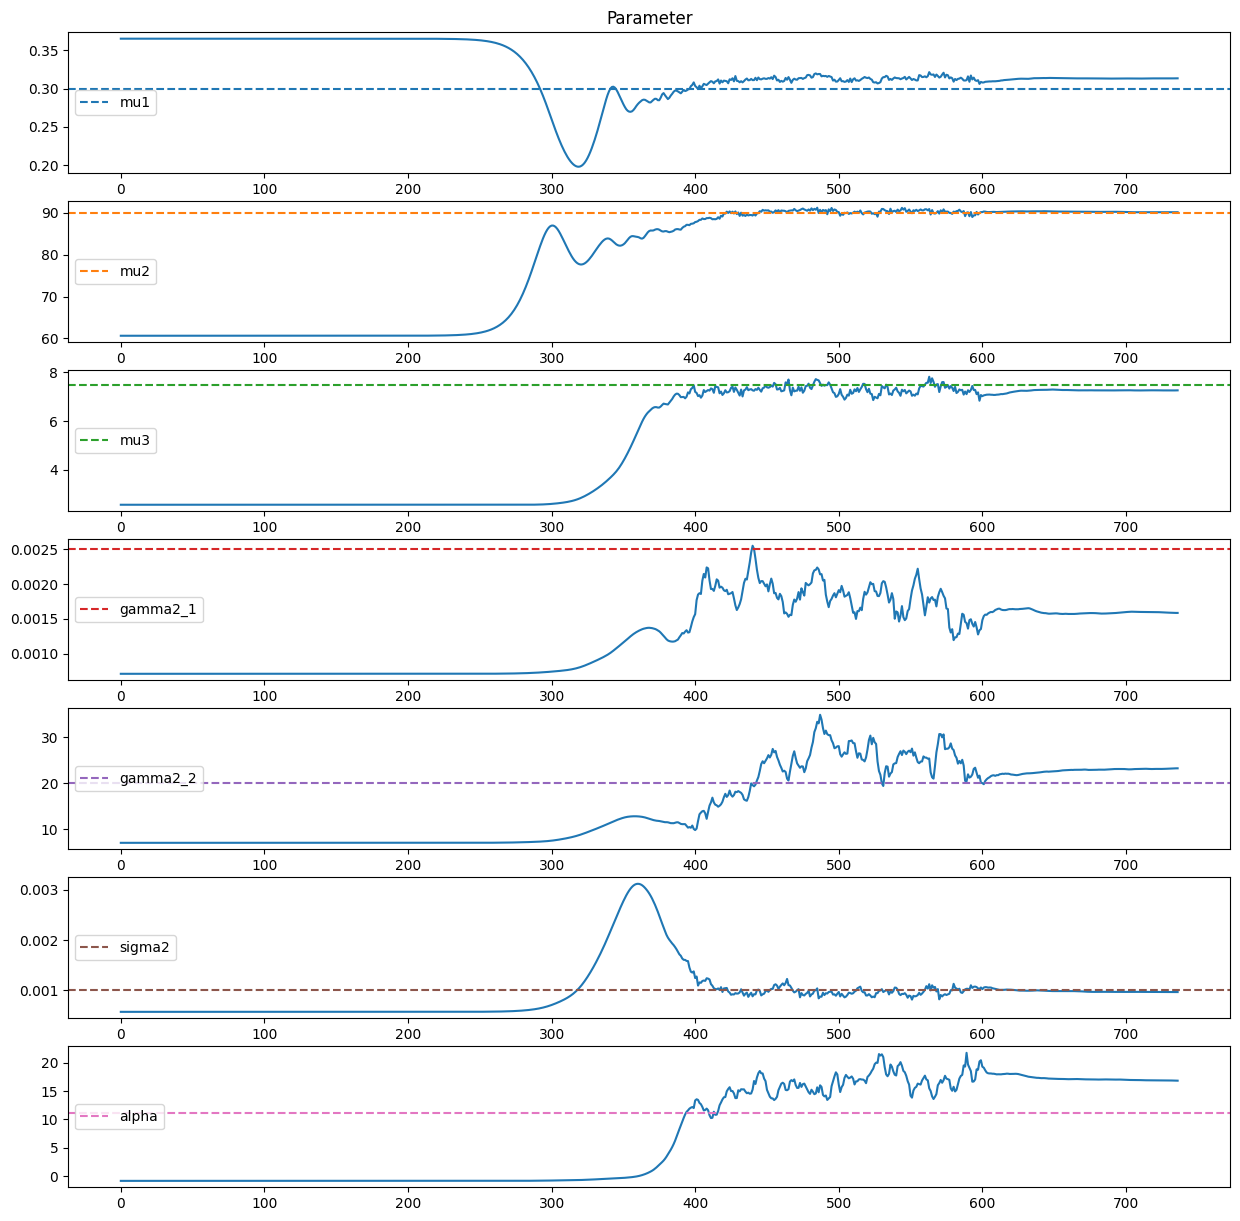

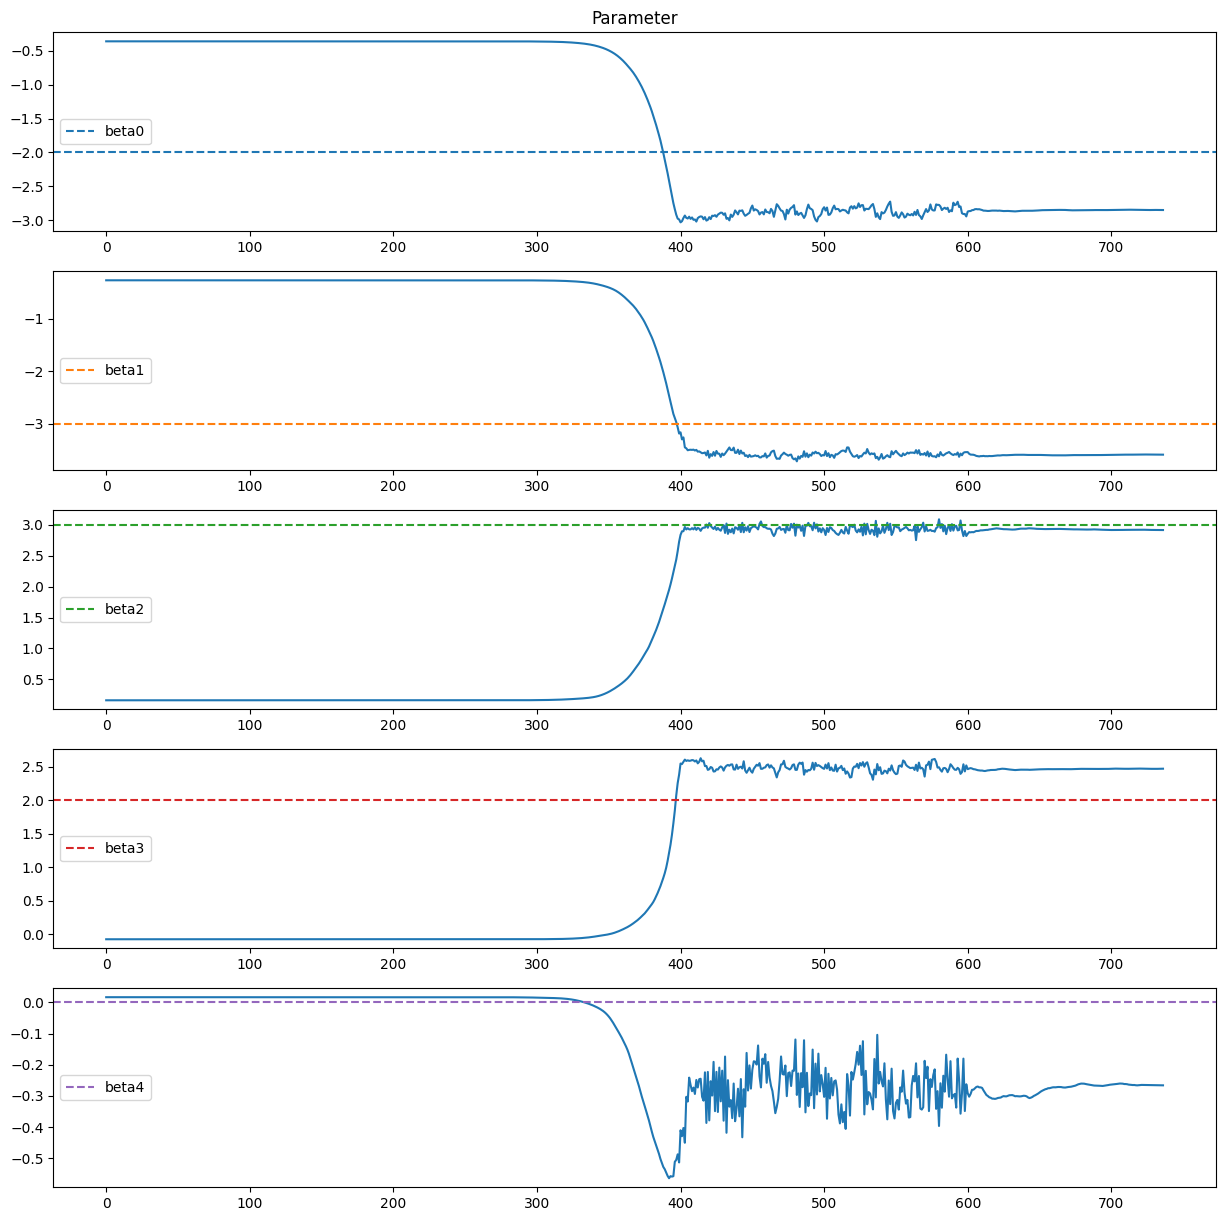

In [6]:
# === PLOT === #
from sdg4varselect.logistic import get_params_star

params_star = get_params_star(model.DIM_HD)

sdgplt.plot_theta(res, model.DIM_LD, params_star, model.params_names)
sdgplt.plot_theta_HD(res, model.DIM_LD, params_star, model.params_names)

# Variable Selection Example

We create a function to encompass all the code to make an estimate to automate the procedure.

In [7]:
def estim(PRNGKey, model, dh, lbd=None, alpha=1.0, save_all=False):
    PRNGKey_theta, PRNGKey_estim, PRNGKey_likelihoohd = jrd.split(PRNGKey, 3)
    theta0 = 0.2 * jrd.normal(PRNGKey_theta, shape=(model.parametrization.size,))

    params0 = model.parametrization.reals1d_to_params(theta0)
    algo = SPG_FIM(PRNGKey_estim, dh, algo_settings, lbd=lbd, alpha=alpha)
    # =================== MCMC configuration ==================== #
    algo.add_mcmc(
        float(params0.mu1),
        sd=0.001,
        size=model.N,
        likelihood=model.likelihood_array,
        name="phi1",
    )
    algo.latent_variables["phi1"].adaptative_sd = True
    algo.add_mcmc(
        float(params0.mu2),
        sd=2,
        size=model.N,
        likelihood=model.likelihood_array,
        name="phi2",
    )
    algo.latent_variables["phi2"].adaptative_sd = True
    # ==================== END configuration ==================== #
    try:
        res_estim = algo.fit(
            model.jac_likelihood,
            DIM_HD=model.DIM_HD,
            theta0_reals1d=theta0,
            ntry=5,
            partial_fit=False,
        )
    except NanError as err:
        print(err)
        return NanError

    res = algo.labelswitch(res_estim)

    theta = jnp.array([model.reals1d_to_hstack_params(t) for t in res.theta])
    return estim_res(
        theta=theta,
        FIM=res.FIM,
        grad=res.grad,
        likelihood=algo.likelihood_marginal(model, PRNGKey_likelihoohd, res.theta[-1]),
    )

We use this function to perform an estimatation for different regularization values

In [8]:
from sdg4varselect.algo import regularization_path
from sdg4varselect.logistic import sample_one

dh = sample_one(jrd.PRNGKey(0), model, weibull_censoring_loc=2000)

lbd_set = 10 ** jnp.linspace(-1, -0.7, num=0)

reg_path = regularization_path(
    estim,
    jrd.PRNGKey(0),
    model,
    dh,
    lbd_set,
    save_all=True,
    verbatim=True,
)

We can now compute de BIC criterion

In [9]:
from sdg4varselect.algo import BIC

DIM_LD = model.DIM_LD
multi_theta_HD = jnp.array([res.theta[-1, DIM_LD:] for res in reg_path])
bic = BIC(multi_theta_HD, jnp.array([res.likelihood for res in reg_path]), model.N)

ValueError: axis 1 is out of bounds for array of dimension 1

and plot the regularization path

In [ ]:
fig, ax = sdgplt.plot_reg_path(lbd_set, reg_path, bic, model.DIM_HD)

ax_bic = ax[1]
# minimum value of bic
id_min = jnp.nanargmax(bic[1:] - bic[:-1])
ax_bic = sdgplt.plot_axvline(ax_bic, lbd_set, bic, id_min, color="g", msg=" = big jump")

ax_bic.legend()

In [ ]:
# === FINAL ESTIMATION === #
lbd_id = jnp.argmin(bic)
selected_component = multi_theta_HD[lbd_id] != 0
theta_biased = reg_path[lbd_id].theta[-1]
NEW_DIM_HD = int(selected_component.sum())

model_shrink = Logistic_JM(N=model.N, J=model.J, DIM_HD=NEW_DIM_HD)
dh_shrink = dh.deepcopy()
dh_shrink.data["cov"] = dh.data["cov"][:, selected_component]

res_estim = estim(jrd.PRNGKey(0), model_shrink, dh_shrink, lbd=None, save_all=True)

# === THETA RE CONSTRUCTION === #
id = jnp.concatenate([jnp.repeat(True, model_shrink.DIM_LD), selected_component])

theta = jnp.zeros(shape=(model.parametrization.size,))
theta = theta.at[jnp.where(id)].set(res_estim.theta[-1, :])

In [ ]:
# === PLOT === #
from sdg4varselect.logistic import get_params_star

params_star = get_params_star(model.DIM_HD)

sdgplt.plot_theta(res_estim, model.DIM_LD, params_star, model.params_names)
sdgplt.plot_theta_HD(res_estim, model.DIM_LD, params_star, model.params_names)

In [ ]:
def estim_full(PRNGKey, model, dh, lbd=None, alpha=1.0, save_all=False):
    res_first_estim = estim(jrd.PRNGKey(0), model, dh, lbd, save_all=True)

    # === FINAL ESTIMATION === #
    theta_biased = res_first_estim.theta[-1]
    NEW_DIM_HD = int(selected_component.sum())

    model_shrink = Logistic_JM(N=model.N, J=model.J, DIM_HD=NEW_DIM_HD)
    dh_shrink = dh.deepcopy()
    dh_shrink.data["cov"] = dh.data["cov"][:, selected_component]

    res_second_estim = estim(
        jrd.PRNGKey(0), model_shrink, dh_shrink, lbd=None, save_all=True
    )

    # === THETA RE CONSTRUCTION === #
    id = jnp.concatenate([jnp.repeat(True, model_shrink.DIM_LD), selected_component])

    theta = jnp.zeros(shape=(model.parametrization.size,))
    theta = theta.at[jnp.where(id)].set(res_second_estim.theta[-1, :])
    res_second_estim = estim_res(
        theta=theta,
        FIM=res_second_estim.FIM,
        grad=res_second_estim.grad,
        likelihood=res_second_estim.likelihood,
    )
    return res_first_estim

In [ ]:
from sdg4varselect.algo import regularization_path
from sdg4varselect.logistic import sample_one

dh = sample_one(jrd.PRNGKey(0), model, weibull_censoring_loc=2000)

lbd_set = 10 ** jnp.linspace(-1, -0.7, num=5)

reg_path = regularization_path(
    estim,
    jrd.PRNGKey(0),
    model,
    dh,
    lbd_set,
    save_all=True,
    verbatim=True,
)

from sdg4varselect.algo import BIC

DIM_LD = model.DIM_LD
multi_theta_HD = jnp.array([res.theta[-1, DIM_LD:] for res in reg_path])
bic = BIC(multi_theta_HD, jnp.array([res.likelihood for res in reg_path]), model.N)

In [ ]:
fig, ax = sdgplt.plot_reg_path(lbd_set, reg_path, bic, model.DIM_HD)

ax_bic = ax[1]
# minimum value of bic
id_min = jnp.nanargmax(bic[1:] - bic[:-1])
ax_bic = sdgplt.plot_axvline(ax_bic, lbd_set, bic, id_min, color="g", msg=" = big jump")

ax_bic.legend()